### Kursbezeichnung:

Projekt: Programmierung mit Python (DLBFTPPP01)

### Aufgabenstellung 2:

Vergleich von Aktien

### Studiengang:

Softwareentwicklung

### Datum:

xx.xx.2026

### Verfasser:

Dustin Vetter, Matrikelnummer IU14110854

# Wer gewinnt das KI-Wettrüsten?

## Ein Aktienvergleich entlang der KI-Wertschöpfungskette

### Gliederung

1. Einleitung
2. Projektvorgehen
3. Kennzahlen zu Rendite und Risiko
4. Gesamtbild und Vergleich
5. Fazit und Reflexion

# 1. Einleitung

## Aktualität und Relevanz des Themas

- Veröffentlichung von ChatGPT Ende 2022 als öffentlich wahrgenommener Auslöser des aktuellen KI-Booms
- Seitdem deutlich steigende Investitionen großer Technologiekonzerne in KI-Infrastruktur
- Generative KI-Anwendungen haben sich zu einem strategischen Schwerpunkt der gesamten Technologiebranche entwickelt

## Untersuchungsgegenstand

- Der öffentlichen Diskurs dreht sich hauptsächlich um generative KI, z. B. ChatGPT, Claude und Mistral AI
- Diese Unternehmen sind privat finanziert und (noch) nicht börsennotiert, es liegen keine Kursdaten vor
- Deshalb werden zentrale Investitionspartner betrachtet mit unmittelbaren Bezug zur KI-Wertschöpfungskette

### Untersuchte Hardware-Unternehmen

- ASML (Niederlande): Lithografieanlagen für die Chipfertigung
- TSMC (Taiwan): größter Auftragsfertiger von Halbleitern
- NVIDIA (USA): marktführende KI-Grafikprozessoren

### Untersuchte Software-Unternehmen

- Microsoft (USA): Cloud-Plattform Azure, Investor bei OpenAI (ChatGPT)
- Amazon (USA): Cloud-Plattform AWS, Investor bei Anthropic (Claude)

## Zielsetzung und Leitfrage

### Leitfrage

Bewegen sich die Aktienkurse von Unternehmen derselben Ebene (Hardware bzw. Software) stärker im Gleichlauf als die Kurse von Unternehmen unterschiedlicher Ebenen?

### Annahme

* Aktien innerhalb derselben Ebene verhalten sich tendenziell ähnlicher als über die Ebenen hinweg
* Hardware-Ebene: stärkerer Gleichlauf zu erwarten, da sch die Unternehmen in der Lieferkette ergänzen statt konkurrieren
* Software-Ebene: schwächerer Gleichlauf zu erwarten, da die Unternehmen im direkten Wettbewerb um Marktanteile stehen

### Überprüfung

Die Annahme wird im weiteren Verlauf anhand einer Korrelationsanalyse der Aktienrendite überprüft. Das methodische Vorgehen dazu folgt im nächsten Kapitel.

# 2. Projektvorgehen

## Import der benötigten Bibliotheken

In [1]:
import yfinance
import pandas
import plotly.express

- yfinance für den Datenabruf
- pandas für die Datenverarbeitung
- plotly für die interaktive Visualisierung

## Abruf der Kursdaten

In [2]:
hardware_unternehmen = ["NVDA", "TSM", "ASML"]
software_unternehmen = ["MSFT", "AMZN"]
alle_unternehmen = hardware_unternehmen + software_unternehmen

alle_daten = yfinance.download(alle_unternehmen, start="2021-08-01", end="2026-07-31", auto_adjust=True)

[*********************100%***********************]  5 of 5 completed


* **start**: Startdatum, 01.08.2021
* **end**: Enddatum, 31.07.2026
* **auto_adjust**: Bereinigt Kurse um Aktiensplits und Dividenden

### Begriffserklärung

- **Aktiensplit**: Aufteilung einer Aktie in mehrere neue Aktien bei gleichbleibendem Gesamtwert des Investments (TODO: Quelle)
    - Beispiel: 1 Aktie zu 1000 USD wird zu 10 Aktien zu je 100 USD
    - Ohne Bereinigung würde ein Split in den historischen Daten wie ein Kurssturz aussehen
* **Dividende**: Ausschüttung eines Teils des Unternehmensgewinns an die Aktionäre (TODO: Quelle)
    - Der Kurs sinkt am Auszahlungstag rechnerisch um den ausgeschütteten Betrag, ohne dass ein realer Wertverlust vorliegt

## Prüfen, ob die Daten korrekt geladen wurden

In [3]:
alle_daten.head()

Price            Close                                                 \
Ticker            AMZN        ASML        MSFT       NVDA         TSM   
Date                                                                    
2021-08-02  166.574005  734.308411  272.827301  19.681923  107.721458   
2021-08-03  168.311996  743.735046  275.030304  19.746696  109.150253   
2021-08-04  167.735992  758.952454  274.445984  20.204117  109.454422   
2021-08-05  168.799500  758.255920  277.329285  20.565861  109.896912   
2021-08-06  167.246994  747.312683  277.271881  20.295799  108.965881   

Price             High                                                 ...  \
Ticker            AMZN        ASML        MSFT       NVDA         TSM  ...   
Date                                                                   ...   
2021-08-02  167.945999  740.214174  274.695176  19.892196  109.122590  ...   
2021-08-03  169.550003  744.612785  275.135687  20.152293  109.362263  ...   
2021-08-04  169.444000  761.900590  275.480496  20.247966  110.201084  ...   
2021-08-05  169.449997  768.645877  277.434668  20.661530  109.915345  ...   
2021-08-06  168.750000  751.043115  277.310205  20.499097  109.325382  ...   

Price             Open                                                 \
Ticker            AMZN        ASML        MSFT       NVDA         TSM   
Date                                                                    
2021-08-02  167.654999  735.415119  274.302436  19.632096  108.311409   
2021-08-03  167.035995  735.148314  273.401903  19.671954  108.136268   
2021-08-04  168.967499  755.641820  274.168187  19.921095  109.168667   
2021-08-05  167.811005  768.521842  274.800461  20.429334  109.758640   
2021-08-06  168.750000  748.476634  276.361900  20.453256  109.113373   

Price         Volume                                        
Ticker          AMZN    ASML      MSFT       NVDA      TSM  
Date                                                        
2021-08-02  67078000  499900  16267400  217444000  6028800  
2021-08-03  83146000  533700  17879000  301811000  5874700  
2021-08-04  43678000  629700  16191300  231309000  4254000  
2021-08-05  48670000  723700  13900200  211435000  4452300  
2021-08-06  52752000  556900  16589300  178497000  4338100  

[5 rows x 25 columns]

### Begriffserklärung
* **Close**: Schlusskurs, letzter gehandelter Preis am jeweiligen Handelstag
* **High**: Höchster gehandelter Preis am jeweiligen Handelstag
* **Low**: Niedrigster gehandelter Preis am jeweiligen Handelstag
* **Open**: Eröffnungskurs, erster gehandelter Preis am jeweiligen Handelstag
* **Volume**: Handelsvolumen, Anzahl der an diesem Tag gehandelten Aktien

## Nur die Schlusskurse anzeigen

* Der Schlusskurs (**Close**) ist für die Rendite- und Risikoberechnung relevante Referenzgröße

In [4]:
close = alle_daten["Close"]
close.head()

Ticker,AMZN,ASML,MSFT,NVDA,TSM
Date,,,,,
2021-08-02,166.574005,734.308411,272.827301,19.681923,107.721458
2021-08-03,168.311996,743.735046,275.030304,19.746696,109.150253
2021-08-04,167.735992,758.952454,274.445984,20.204117,109.454422
2021-08-05,168.799500,758.255920,277.329285,20.565861,109.896912
2021-08-06,167.246994,747.312683,277.271881,20.295799,108.965881


## Bedeutung der Zahlen

* **166.574005**: Eine Aktie von Amazon hatte am Schlusskurs vom 02.08.2021 einen Wert von ca. 166,57 USD

## Tägliche Rendite berechnen

### Begriffserklärung

- **Rendite**:
    - Definition: Prozentuale Wertveränderung einer Kapitalanlage über einen bestimmten Zeitraum, bezogen auf das eingesetzte Kapital (TODO: Quelle)
    - Beispiel: Ein Investment von 100 EUR wächst auf 110 EUR => Rendite = 10 %
- **Tägliche Rendite**:
    - Definition: Rendite bezogen auf einen einzelnen Handelstag (TODO: Quelle)
    - Formel: `(Kurs heute - Kurs Vortag) / Kurs Vortag`
    - Umsetzung in Python:
        - Die Methode `pct_change()` (percentage change) wendet genau diese Formel auf jede Spalte bzw. Unternehmen an (pandas, n. d.)
        - Die Methode `dropna()` (drop NA) entfernt fehlende Einträge (pandas, n. d.)
        - Das betrifft hier nur den ersten Handelstag, da es dort keinen Vortageskurs gibt

In [5]:
taegliche_rendite = close.pct_change().dropna()
taegliche_rendite.head()

Ticker,AMZN,ASML,MSFT,NVDA,TSM
Date,,,,,
2021-08-03,0.010434,0.012837,0.008075,0.003291,0.013264
2021-08-04,-0.003422,0.020461,-0.002125,0.023164,0.002787
2021-08-05,0.006340,-0.000918,0.010506,0.017904,0.004043
2021-08-06,-0.009197,-0.014432,-0.000207,-0.013132,-0.008472
2021-08-09,-0.000918,0.006894,-0.003904,-0.003486,0.000085


### Bedeutung der Zahlen

- **0.010434**: Tägliche Rendite von Amazon am 03.08.2021
    - Der Kurs ist gegenüber dem Vortag (02.08.2021) um 1,0434 % gestiegen
- **-0.003422**: Tägliche Rendite von Amazon am 04.08.2021
    -  Der Kurs ist gegenüber dem Vortag (03.08.2021) um 0,3422 % gefallen

# 3. Kennzahlen zu Rendite und Risiko

In [6]:
farben = {
    "ASML": "#184f95",
    "TSM": "#2a78d6",
    "NVDA": "#6da7ec",
    "MSFT": "#a67c00",
    "AMZN": "#e0a500"
}

## 3.1 Kumulierte Rendite

- **Definition**: Gesamtrendite eines Investments über den gesamten Betrachtungszeitraum, nicht nur über einen einzelnen Tag (TODO: Quelle)
- **Formel**: `Kumulierte Rendite = (Endkapital / Startkapital) - 1`
- **Umsetzung in Python**:
    - `1 + taegliche_rendite` wandelt jede Tagesrendite in einen Wachstumsfaktor um, z. B. wird aus +2 % der Faktor 1,02
    - `cumprod()` (cumulative product) liefert das kumulierte Produkt über eine (Zeit-)Achse, multipliziert also alle Wachstumsfaktoren bis zu einem bestimmten Tag miteinander und ergibt so den Vermögensfaktor an diesem Tag (pandas, n. d.)
    - `- 1` wandelt den Vermögensfaktor wieder in eine Rendite um

In [7]:
kumulierte_rendite = (1 + taegliche_rendite).cumprod() - 1
kumulierte_rendite.tail()

Ticker,AMZN,ASML,MSFT,NVDA,TSM
Date,,,,,
2026-07-24,0.393435,1.389759,0.396425,9.509136,2.744936
2026-07-27,0.389112,1.251264,0.423497,8.984288,2.704833
2026-07-28,0.385931,1.155702,0.439046,9.009692,2.641893
2026-07-29,0.360656,1.111769,0.428765,8.654036,2.478137
2026-07-30,0.413786,1.248973,0.650320,8.909601,2.744008


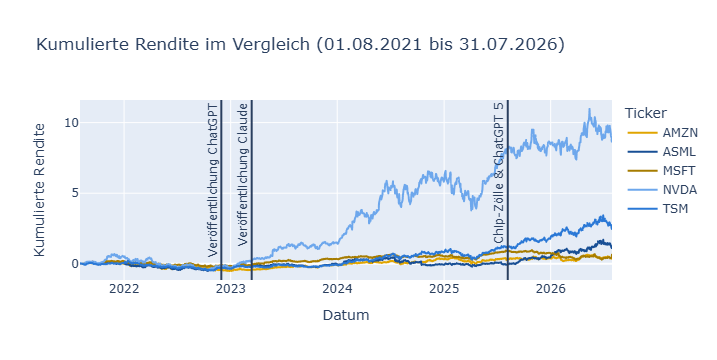

In [8]:
figur_kumulierte_rendite = plotly.express.line(
    kumulierte_rendite,
    color_discrete_map=farben,
    labels={"value": "Kumulierte Rendite", "Date": "Datum"},
    title="Kumulierte Rendite im Vergleich (01.08.2021 bis 31.07.2026)"
)

figur_kumulierte_rendite.add_vline(
    x=pandas.Timestamp("2022-11-30"),
    annotation_text="Veröffentlichung ChatGPT",
    annotation_position="top left",
    annotation_textangle=270
)

figur_kumulierte_rendite.add_vline(
    x=pandas.Timestamp("2023-03-14"),
    annotation_text="Veröffentlichung Claude",
    annotation_position="top left",
    annotation_textangle=270
)

figur_kumulierte_rendite.add_vline(
    x=pandas.Timestamp("2025-08-07"),
    annotation_text="Chip-Zölle & ChatGPT 5",
    annotation_position="top left",
    annotation_textangle=270
)

figur_kumulierte_rendite.show()

### Bedeutung der Zahlen

- Ein Wert von 10 bei NVIDIA (Ergebnis von `Kumulierte Rendite = (Endkapital / Startkapital) - 1`) bedeutet eine kumulierte Rendite von 1000 %
- Aufgelöst nach dem Endkapital: `Endkapital = Startkapital x (1 + Kumulierte Rendite)`
- Aus 1 EUR wären also 11 EUR geworden (`1 EUR x (1 + 10) = 11 EUR`)

### Schlussfolgerung

- Am Ende des Betrachtungszeitraums liegen alle drei Hardware-Unternehmen (blau) deutlich vor beiden Software-Unternehmen (gelb)
- Das stützt die eingangs formulierte Annahme, dass sich die Hardware-Ebene der KI-Wertschöpfungskette bislang stärker ausgezahlt als die Software-Ebene
- Offen bleibt, ob dieses höhere Wachstum auch mit einem höheren Risiko einhergeht, das untersucht die nächste Kennzahl Volatilität

## 3.2 Volatilität

- **Definition**:
    - Maß für die Schwankungsbreite der täglichen Rendite einer Aktie um ihren Mittelwert
    - Hohe Volatilität bedeutet große Kursschwankungen und damit höheres Risiko (TODO: Quelle)
- **Formel**: `Volatilität = Standardabweichung der täglichen Rendite * Wurzel(252)`
- **Umsetzung in Python**:
    - `taegliche_rendite.std()` berechnet die Standardabweichung je Unternehmen (pandas  n. d.)
    - `** 0.5` berechnet die Quadratwurzel von 252 (Anzahl der Handelstage pro Jahr) zur Annualisierung
    - Da sich die Schwankung unabhängiger täglicher Renditen über die Zeit aufsummiert, wächst die Standardabweichung mit der Wurzel der Zeit

In [9]:
volatilitaet = taegliche_rendite.std() * (252 ** 0.5)
volatilitaet

Ticker
AMZN    0.356498
ASML    0.432816
MSFT    0.279891
NVDA    0.518987
TSM     0.383796
dtype: float64

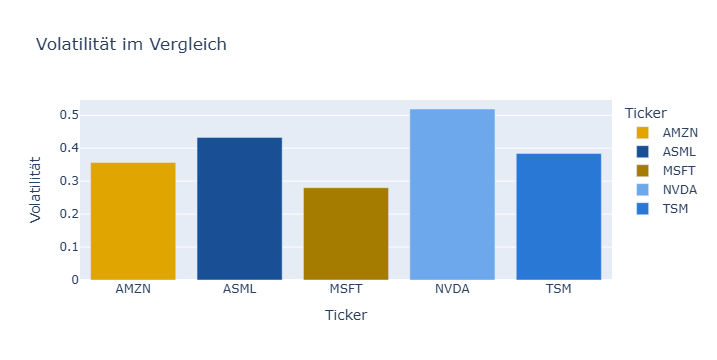

In [10]:
figur_volatilitaet = plotly.express.bar(
    volatilitaet,
    color=volatilitaet.index,
    color_discrete_map=farben,
    labels={"value": "Volatilität", "color": "Ticker"},
    title="Volatilität im Vergleich"
)

figur_volatilitaet.show()

### Bedeutung der Zahlen

- Bei 100 EUR Einsatz bedeutet eine Volatilität von ca. 0,52 (NVIDIA), dass der Wert im Jahresverlauf um ca. 52 EUR nach oben oder unten schwankt
- Eine Volatilität von ca. 0,28 (Microsoft) bedeutet eine Schwankung von ca. 28 EUR

### Schlussfolgerung

- Die Hardware-Ebene zeigte in 3.1 nicht nur eine höhere kumulierte Rendite, sondern hier auch eine höhere Volatität
- Höhere Renditechancen gehen mit größeren Kursschwankungen einher
- Offen bleibt, ob ob sich dieses höhere Risiko im Verhältnis zur erzielten Rendite tatsächlich gelohnt hat, das misst die nächste Kennzahl Sharpe Ratio

## 3.3 Sharpe Ratio

## 3.4 Maximaler Drawdown

## 3.5 Korrelation / Diversifikation

# 4. Gesamtbild und Vergleich

# 5. Fazit und Reflexion

# Abbildungsverzeichnis

# Quellenverzeichnis